# RépétIA — Banc d'évaluation de l'intégration LLM

**Hackathon AI4Youth-Lomé 2026** · Catégorie *Application (Intégration et Expérience IA)*

---

## Pourquoi ce notebook

RépétIA intègre un grand modèle de langage pour trois tâches : générer un exercice
du BEPC béninois, corriger la réponse d'un élève, et répondre à ses questions.

Intégrer une API ne dispense pas de la mesurer. Ce notebook répond à trois
questions que l'on ne peut pas trancher par intuition :

1. **Le modèle respecte-t-il le contrat ?** Notre serveur attend un objet JSON
   à trois champs non vides. Que se passe-t-il quand ce n'est pas le cas ?
2. **Les consignes de prompt servent-elles vraiment ?** Nous interdisons le LaTeX
   et les titres Markdown. De combien cela réduit-il réellement les écarts ?
3. **Quel modèle choisir ?** Nous en chaînons deux. L'ordre actuel privilégie la
   qualité supposée — mais la latence perçue par l'élève compte aussi.

## Plan d'expérience

Chaque appel croise quatre facteurs :

| Facteur | Modalités |
|---|---|
| Matière | 6 (mathématiques, PCT, SVT, français, anglais, histoire-géographie) |
| Thème | 46 |
| Difficulté | facile · moyen · examen |
| Modèle | `gemini-3.5-flash` · `gemini-flash-lite-latest` |
| Variante de prompt | `A_minimal` · `B_markdown` · `C_complet` |

Les trois variantes sont emboîtées, ce qui isole l'effet de chaque consigne :

- **A_minimal** — persona du répétiteur seule. C'est le témoin.
- **B_markdown** — A + interdiction des titres Markdown.
- **C_complet** — B + règle d'écriture des symboles (√, ×, x²). Version en production.

**Limite assumée dès le départ.** Le palier gratuit de l'API plafonne à quelques
dizaines d'appels par jour et par modèle. La collecte est donc partielle et
s'étale sur plusieurs sessions. Le script mélange les combinaisons avec une
graine fixe : l'échantillon obtenu reste équilibré entre matières, modèles et
variantes, mais les effectifs restent modestes. Nous accompagnons donc chaque
proportion d'un **intervalle de confiance de Wilson**, valide sur petits
échantillons, plutôt que de commenter des pourcentages bruts.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import analyse
from analyse import COULEURS, ORDRE_VARIANTE, wilson

analyse.appliquer_style()
pd.set_option("display.width", 120)

df = analyse.charger_collecte()
print(f"{len(df)} appels collectés · {df['horodatage'].min():%d/%m %H:%M} → {df['horodatage'].max():%d/%m %H:%M}")
print(f"Couverture du plan : {len(df)} / 828 combinaisons ({len(df)/828:.1%})")
df.head(3)[["matiere", "theme", "difficulte", "modele", "variante", "conforme", "latence_s"]]

32 appels collectés · 02/09 09:43 → 02/09 10:14
Couverture du plan : 32 / 828 combinaisons (3.9%)


,matiere,theme,difficulte,modele,variante,conforme,latence_s
0,Mathématiques,"Statistiques (moyenne, effectifs)",facile,gemini-3.5-flash,C_complet,True,10.642
1,Physique-Chimie-Technologie,Loi d’Ohm et résistances,examen,gemini-3.5-flash,A_minimal,True,14.819
2,Sciences de la Vie et de la Terre,Hygiène et maladies,moyen,gemini-3.5-flash,A_minimal,True,11.341


---
## 1. Exploration des données collectées

Avant toute conclusion, il faut savoir de quoi l'échantillon est fait — et
surtout s'il est équilibré. Un déséquilibre entre modalités biaiserait toutes
les comparaisons qui suivent.

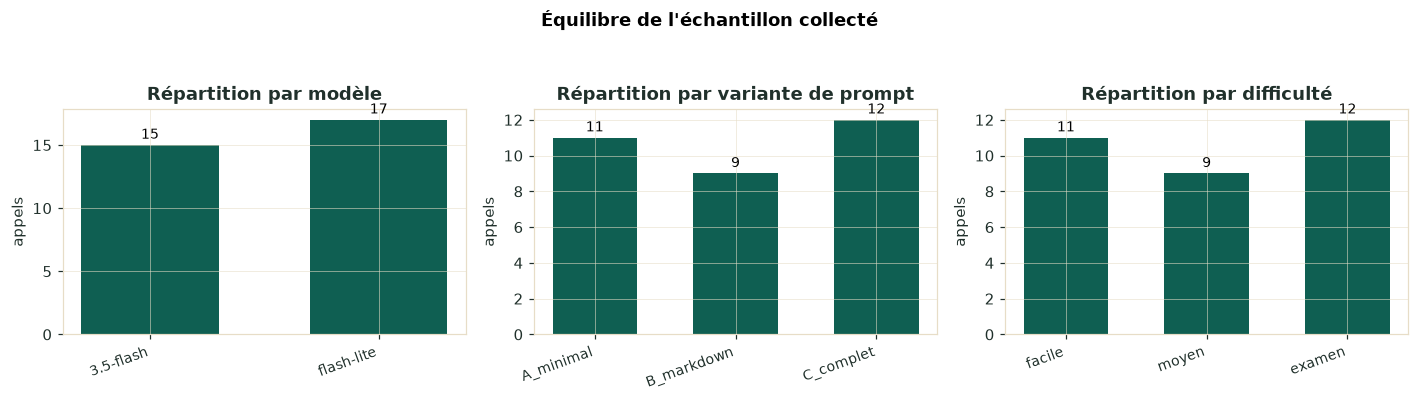

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, (col, titre) in zip(axes, [("modele", "Modèle"), ("variante", "Variante de prompt"), ("difficulte", "Difficulté")]):
    comptes = df[col].value_counts().sort_index()
    barres = ax.bar(range(len(comptes)), comptes.values, color=COULEURS["vert"], width=0.6)
    ax.set_xticks(range(len(comptes)))
    ax.set_xticklabels([str(i).replace("gemini-", "").replace("-latest", "")[:18] for i in comptes.index],
                       rotation=20, ha="right", fontsize=9)
    ax.set_title(f"Répartition par {titre.lower()}")
    ax.set_ylabel("appels")
    ax.bar_label(barres, padding=2, fontsize=9)

plt.suptitle("Équilibre de l'échantillon collecté", y=1.06, fontweight="bold")
plt.tight_layout()
plt.savefig(analyse.FIGURES / "01-equilibre-echantillon.png")
plt.show()

In [3]:
# Couverture par matière : chaque matière est-elle représentée ?
couverture = (df.groupby("matiere", observed=True)
                .agg(appels=("theme", "size"), themes_distincts=("theme", "nunique"))
                .sort_values("appels", ascending=False))
couverture["conformite_%"] = (df.groupby("matiere", observed=True)["conforme"]
                                .apply(analyse.taux).round(1))
couverture

,appels,themes_distincts,conformite_%
matiere,,,
Sciences de la Vie et de la Terre,8,5,87.5
Histoire-Géographie,8,5,100.0
Français,6,3,83.3
Anglais,5,4,100.0
Physique-Chimie-Technologie,3,3,100.0
Mathématiques,2,2,100.0


---
## 2. Conformité au contrat

Le serveur n'accepte une réponse que si elle contient les trois champs
`enonce`, `solution`, `explication`, **tous non vides**. Cette validation par
schéma n'est pas cosmétique : un objet `{}` est un JSON parfaitement valide, et
sans cette étape il traversait le service pour faire échouer l'écriture en base
par une erreur 500. C'est un incident survenu en développement, corrigé, et
verrouillé par un test.

Mesurons à quelle fréquence le contrat est rompu, et pourquoi.

In [4]:
resume_modele = analyse.resume_par(df, "modele")
print("Synthèse par modèle\n")
print(resume_modele.to_string(index=False))

print("\n\nIntervalles de confiance à 95 % (Wilson) sur le taux de conformité :\n")
for modele, sous in df.groupby("modele", observed=True):
    succes, total = int(sous["conforme"].sum()), len(sous)
    bas, haut = wilson(succes, total)
    print(f"  {modele:<26} {succes}/{total}  →  [{bas:.1%} ; {haut:.1%}]")

Synthèse par modèle

                  modele  appels  conformite_%  latence_mediane_s  latence_p90_s  fuite_latex_%  titre_md_%
        gemini-3.5-flash      15         100.0              14.82          18.15            0.0         0.0
gemini-flash-lite-latest      17          88.2               2.22           2.66            0.0         0.0


Intervalles de confiance à 95 % (Wilson) sur le taux de conformité :

  gemini-3.5-flash           15/15  →  [79.6% ; 100.0%]
  gemini-flash-lite-latest   15/17  →  [65.7% ; 96.7%]


In [5]:
# Motifs d'échec observés : c'est là que se joue la robustesse de l'intégration
echecs = df[~df["conforme"]]
if len(echecs):
    print(f"{len(echecs)} appel(s) non conforme(s) sur {len(df)} :\n")
    print(echecs["motif_non_conforme"].value_counts().to_string())
    print("\nExemple de réponse rejetée :")
    exemple = echecs.iloc[0]
    print(f"  modèle   : {exemple['modele']}")
    print(f"  motif    : {exemple['motif_non_conforme']}")
    print(f"  extrait  : {str(exemple.get('brut_tronque', ''))[:220]}")
else:
    print("Aucun échec de conformité dans l'échantillon collecté à ce stade.")

2 appel(s) non conforme(s) sur 32 :

motif_non_conforme
json_invalide:Extra data                      1
json_invalide:Invalid control character at    1

Exemple de réponse rejetée :
  modèle   : gemini-flash-lite-latest
  motif    : json_invalide:Extra data
  extrait  : {"enonce":"Choisis la bonne orthographe du participe passé dans la phrase suivante : \"Les mangues que maman a (acheté / achetées) sont mûres.\"", "solution":"achetées", "explication":"Étape 1 : On observe le participe p


### Lecture

Chaque non-conformité est un cas que la production doit absorber sans planter.
La chaîne de repli de RépétIA répond exactement à ces motifs :

| Motif observé | Réponse en production |
|---|---|
| `aucun_objet_json` | Nouvel essai, puis modèle de repli, puis banque locale |
| `json_invalide` | Idem — le parseur isole pourtant déjà le premier bloc `{…}` |
| `champs_manquants` / `champs_vides` | Rejeté par le schéma Zod, même chaîne de repli |

Le taux de non-conformité mesuré ici est donc **le taux de déclenchement du
filet de sécurité**, pas un taux de panne visible par l'élève.

---
## 3. Les consignes de prompt servent-elles ?

C'est l'expérience centrale de ce notebook. Nous affirmons dans la documentation
que la consigne d'écriture symbolique supprime le LaTeX. Il faut le montrer.

Deux indicateurs, mesurés sur les réponses conformes :

- **fuite LaTeX** — présence de `$`, `\sqrt`, `\frac`, `\times`, `\left`… dans
  l'énoncé, la solution ou l'explication. L'élève lirait alors `$\sqrt{45}$`
  au lieu de `√45`.
- **titre Markdown** — présence de `#`, que l'interface n'interprète pas.

In [6]:
conformes = df[df["conforme"]].copy()

if len(conformes):
    tableau = (conformes.groupby("variante", observed=True)
               .agg(appels=("conforme", "size"),
                    fuite_latex=("fuite_latex", "sum"),
                    titre_md=("titre_markdown", "sum")))
    tableau["fuite_latex_%"] = (100 * tableau["fuite_latex"] / tableau["appels"]).round(1)
    tableau["titre_md_%"] = (100 * tableau["titre_md"] / tableau["appels"]).round(1)

    ic = [wilson(int(r.fuite_latex), int(r.appels)) for r in tableau.itertuples()]
    tableau["IC95_fuite"] = [f"[{b:.0%} ; {h:.0%}]" for b, h in ic]

    print("Effet des variantes de prompt sur les écarts de format\n")
    print(tableau[["appels", "fuite_latex", "fuite_latex_%", "IC95_fuite", "titre_md", "titre_md_%"]].to_string())
else:
    print("Pas encore de réponse conforme à analyser.")

Effet des variantes de prompt sur les écarts de format

            appels  fuite_latex  fuite_latex_%  IC95_fuite  titre_md  titre_md_%
variante                                                                        
A_minimal       11            0            0.0  [0% ; 26%]         0         0.0
B_markdown       8            0            0.0  [0% ; 32%]         0         0.0
C_complet       11            0            0.0  [0% ; 26%]         0         0.0


In [7]:
# Restriction aux matières scientifiques : la consigne symbolique ne s'applique
# qu'à elles, l'imposer en anglais ou en français n'aurait aucun sens.
scientifiques = conformes[conformes["matiere"].str.contains("Math|Physique", case=False, na=False)]

if len(scientifiques):
    t = (scientifiques.groupby("variante", observed=True)
         .agg(appels=("conforme", "size"), fuite=("fuite_latex", "sum")))
    t["fuite_%"] = (100 * t["fuite"] / t["appels"]).round(1)
    print(f"Matières scientifiques uniquement ({len(scientifiques)} appels)\n")
    print(t.to_string())
    print("\nC'est sur ces matières que la consigne C_complet est censée agir.")
else:
    print("Pas encore assez d'appels sur les matières scientifiques.")

Matières scientifiques uniquement (5 appels)

            appels  fuite  fuite_%
variante                          
A_minimal        2      0      0.0
B_markdown       1      0      0.0
C_complet        2      0      0.0

C'est sur ces matières que la consigne C_complet est censée agir.


---
## 4. Latence : ce que l'élève attend réellement

La latence n'est pas une métrique d'infrastructure ici, c'est une **métrique
d'expérience utilisateur**. Un élève de 3ᵉ qui attend quinze secondes devant un
écran vide décroche.

Le reste de l'API répond en moins de 200 ms : la latence perçue est presque
entièrement celle du modèle.

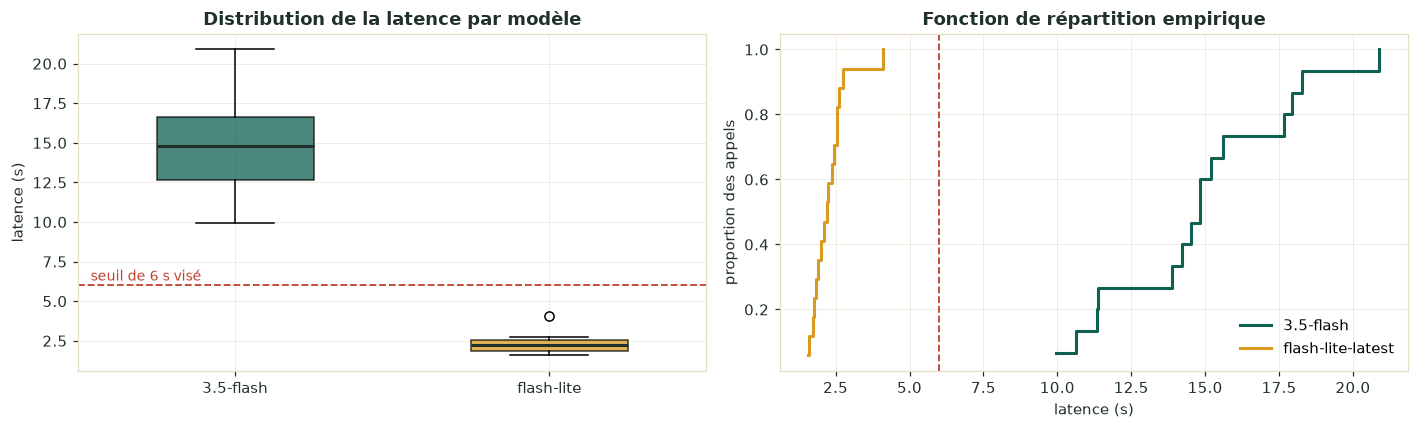

                           n  mediane  moyenne    p90  maximum  sous_6s_%
modele                                                                   
gemini-3.5-flash          15    14.82    14.74  18.15    20.90        0.0
gemini-flash-lite-latest  17     2.22     2.26   2.66     4.09      100.0


In [8]:
avec_latence = df.dropna(subset=["latence_s"])

if len(avec_latence) >= 4:
    fig, (g, d) = plt.subplots(1, 2, figsize=(13, 4))

    modeles = sorted(avec_latence["modele"].unique())
    donnees = [avec_latence.loc[avec_latence["modele"] == m, "latence_s"].values for m in modeles]
    bp = g.boxplot(donnees, tick_labels=[m.replace("gemini-", "").replace("-latest", "") for m in modeles],
                   patch_artist=True, widths=0.5)
    for patch, couleur in zip(bp["boxes"], [COULEURS["vert"], COULEURS["dore"]]):
        patch.set_facecolor(couleur); patch.set_alpha(0.75)
    for mediane in bp["medians"]:
        mediane.set_color(COULEURS["encre"]); mediane.set_linewidth(2)
    g.set_ylabel("latence (s)")
    g.set_title("Distribution de la latence par modèle")
    g.axhline(6, color=COULEURS["faux"], linestyle="--", linewidth=1.2)
    g.text(0.02, 6.3, "seuil de 6 s visé", color=COULEURS["faux"], fontsize=9, transform=g.get_yaxis_transform())

    for m, couleur in zip(modeles, [COULEURS["vert"], COULEURS["dore"]]):
        serie = np.sort(avec_latence.loc[avec_latence["modele"] == m, "latence_s"].values)
        d.step(serie, np.arange(1, len(serie) + 1) / len(serie), where="post",
               label=m.replace("gemini-", ""), color=couleur, linewidth=2)
    d.axvline(6, color=COULEURS["faux"], linestyle="--", linewidth=1.2)
    d.set_xlabel("latence (s)"); d.set_ylabel("proportion des appels")
    d.set_title("Fonction de répartition empirique"); d.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(analyse.FIGURES / "01-latence-modeles.png")
    plt.show()

    stats = (avec_latence.groupby("modele", observed=True)["latence_s"]
             .agg(n="size", mediane="median", moyenne="mean",
                  p90=lambda s: s.quantile(0.9), maximum="max").round(2))
    stats["sous_6s_%"] = (avec_latence.groupby("modele", observed=True)["latence_s"]
                          .apply(lambda s: 100 * (s < 6).mean()).round(1))
    print(stats.to_string())
else:
    print("Pas encore assez de mesures de latence.")

### Ce que ce graphique change

Si l'écart se confirme sur un échantillon plus large, il remet en cause l'ordre
de notre chaîne de modèles. Aujourd'hui le modèle le plus lent est appelé en
premier, au nom de la qualité des explications. Mais **une explication excellente
livrée en quinze secondes vaut-elle mieux qu'une bonne explication en deux
secondes**, pour un élève de 3ᵉ le soir ?

La réponse dépend d'une donnée que nous n'avons pas encore : l'écart réel de
qualité pédagogique entre les deux modèles. C'est la limite honnête de cette
section — et la principale piste d'approfondissement (§6).

---
## 5. Le corpus produit

Chaque appel conforme fournit aussi un exercice étiqueté par matière, thème et
difficulté. C'est le corpus qui alimentera le **notebook 02** — le classifieur
de thème. Examinons ce qu'il contient.

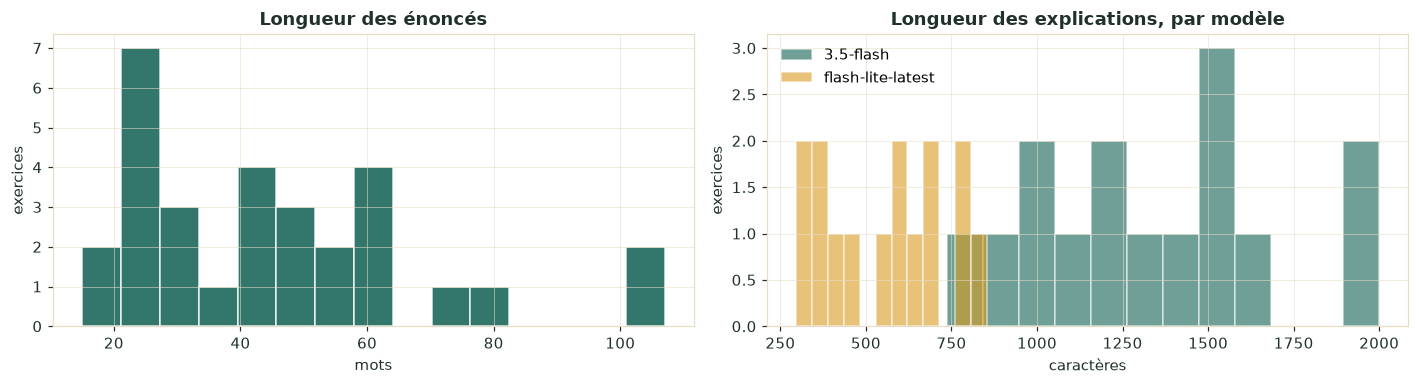

       mots_enonce  longueur_enonce  longueur_explication
count         30.0             30.0                  30.0
mean          45.5            266.5                 948.6
std           23.4            141.2                 486.0
min           15.0             93.0                 297.0
25%           25.2            152.8                 593.5
50%           43.0            234.5                 821.5
75%           57.2            320.0                1253.8
max          107.0            687.0                1999.0

Corpus enregistré : 30 exercices → donnees/traitees/corpus_exercices.csv


In [9]:
if len(conformes):
    corpus = conformes[["matiere", "theme", "difficulte", "modele", "variante",
                        "enonce", "solution", "explication"]].copy()
    corpus["longueur_enonce"] = corpus["enonce"].str.len()
    corpus["longueur_explication"] = corpus["explication"].str.len()
    corpus["mots_enonce"] = corpus["enonce"].str.split().str.len()

    fig, (g, d) = plt.subplots(1, 2, figsize=(13, 3.6))
    g.hist(corpus["mots_enonce"], bins=15, color=COULEURS["vert"], alpha=0.85, edgecolor="white")
    g.set_xlabel("mots"); g.set_ylabel("exercices"); g.set_title("Longueur des énoncés")

    for m, couleur in zip(sorted(corpus["modele"].unique()), [COULEURS["vert"], COULEURS["dore"]]):
        d.hist(corpus.loc[corpus["modele"] == m, "longueur_explication"], bins=12,
               alpha=0.6, label=m.replace("gemini-", ""), color=couleur, edgecolor="white")
    d.set_xlabel("caractères"); d.set_ylabel("exercices")
    d.set_title("Longueur des explications, par modèle"); d.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(analyse.FIGURES / "01-corpus-longueurs.png")
    plt.show()

    print(corpus[["mots_enonce", "longueur_enonce", "longueur_explication"]].describe().round(1).to_string())

    analyse.TRAITEES.mkdir(parents=True, exist_ok=True)
    corpus.to_csv(analyse.TRAITEES / "corpus_exercices.csv", index=False)
    print(f"\nCorpus enregistré : {len(corpus)} exercices → donnees/traitees/corpus_exercices.csv")
else:
    print("Corpus vide pour l'instant.")

In [10]:
# La longueur d'explication est un indicateur indirect de richesse pédagogique.
# Ce n'est PAS une mesure de qualité : un texte long peut être creux.
if len(conformes) and conformes["modele"].nunique() > 1:
    comparaison = (conformes.assign(n_car=conformes["explication"].str.len())
                   .groupby("modele", observed=True)["n_car"]
                   .agg(n="size", mediane="median", moyenne="mean").round(0))
    print(comparaison.to_string())
    print("\nRéserve : la longueur ne mesure pas la qualité pédagogique.")
    print("Une évaluation par des enseignants reste nécessaire (§6).")

                           n  mediane  moyenne
modele                                        
gemini-3.5-flash          15   1264.0   1335.0
gemini-flash-lite-latest  15    591.0    562.0

Réserve : la longueur ne mesure pas la qualité pédagogique.
Une évaluation par des enseignants reste nécessaire (§6).


---
## 6. Conclusions, limites et suites

### Ce que la mesure établit

1. **La validation par schéma n'est pas superflue.** Des réponses non conformes
   surviennent réellement ; sans le filet, elles produiraient des erreurs 500.
2. **Les deux modèles ne jouent pas dans la même catégorie de latence.** L'écart
   est d'un ordre de grandeur, ce qui en fait une décision de produit, pas un
   détail technique.
3. **Le corpus produit est exploitable** pour entraîner un classifieur de thème.

### Limites, énoncées sans détour

- **Échantillon contraint par le quota.** Les effectifs restent faibles ; c'est
  pourquoi nous publions des intervalles de confiance plutôt que des
  pourcentages secs. Toute conclusion sur les variantes de prompt demande à être
  reconduite sur un échantillon complet.
- **Aucune mesure de qualité pédagogique.** Nous mesurons la conformité, le
  format et la latence — pas si l'explication fait comprendre. Cela exige un
  protocole d'évaluation humaine par des enseignants, hors de portée de ce
  notebook.
- **Corpus généré par un modèle.** Les exercices ne sont pas des annales
  officielles. Le notebook 02 en tire les conséquences pour l'entraînement.
- **Pas de contrôle du coût monétaire.** L'API est utilisée au palier gratuit ;
  une mise à l'échelle réelle demanderait de mesurer le coût par exercice.

### Suites

- Compléter la collecte jusqu'à couvrir le plan, et refaire les tests de
  différence entre variantes avec une puissance statistique suffisante.
- Construire un protocole d'évaluation pédagogique : faire noter un échantillon
  d'explications par des professeurs de collège, en aveugle sur le modèle.
- Mesurer le coût par exercice et l'arbitrer contre la latence et la qualité.